In [1]:
import pandas as pd

In [5]:
data=pd.read_csv("Student_Performance.csv")

In [6]:
data.shape

(10000, 6)

In [7]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     10000 non-null  int64 
 1   Previous Scores                   10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


In [11]:
data.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [12]:
encoded_data = pd.get_dummies(data,dtype=int)

In [13]:
encoded_data.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_No,Extracurricular Activities_Yes
0,7,99,9,1,91,0,1
1,4,82,4,2,65,1,0
2,8,51,7,2,45,0,1
3,5,52,5,2,36,0,1
4,7,75,8,5,66,1,0


In [14]:
X = encoded_data.drop('Performance Index', axis=1)
y = encoded_data['Performance Index']               

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [16]:
from sklearn.linear_model import LinearRegression
Performance_predict=LinearRegression()
Performance_predict.fit(X_train, y_train)

LinearRegression()

# formula (y=mx+b)

In [17]:
Performance_predict.coef_ #value of m(slope)

array([ 2.85248393,  1.0169882 ,  0.47694148,  0.19183144, -0.30430834,
        0.30430834])

In [18]:
Performance_predict.intercept_ #(value of b)

np.float64(-33.617637875768075)

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred_train = Performance_predict.predict(X_train)
train_error = mean_squared_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

In [24]:
train_error

4.169735849525006

In [25]:
train_r2

0.9886898790682355

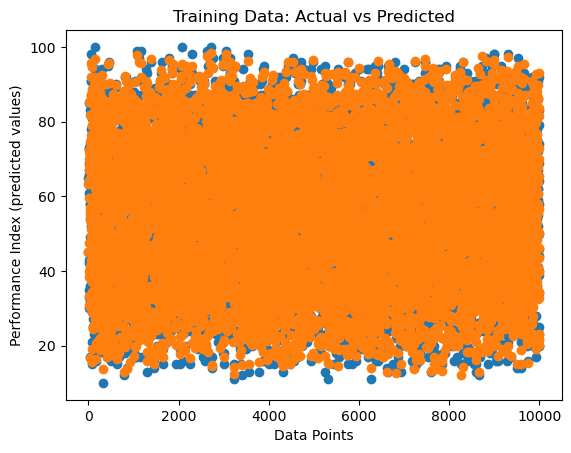

In [39]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(x=X_train.index,y=y_train)
plt.scatter(x=X_train.index,y=y_pred_train)
plt.xlabel("Data Points")
plt.ylabel("Performance Index (predicted values)")
plt.title("Training Data: Actual vs Predicted")
plt.savefig("plot.png")
plt.show()

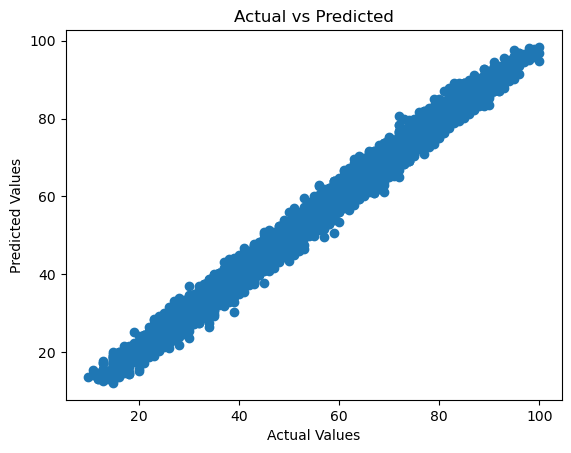

In [38]:
plt.figure()
plt.scatter(y_train, y_pred_train)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [23]:
y_pred_test = Performance_predict.predict(X_test)
test_error = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

In [26]:
test_error

4.0826283985218605

In [27]:
test_r2

0.9889832909573145

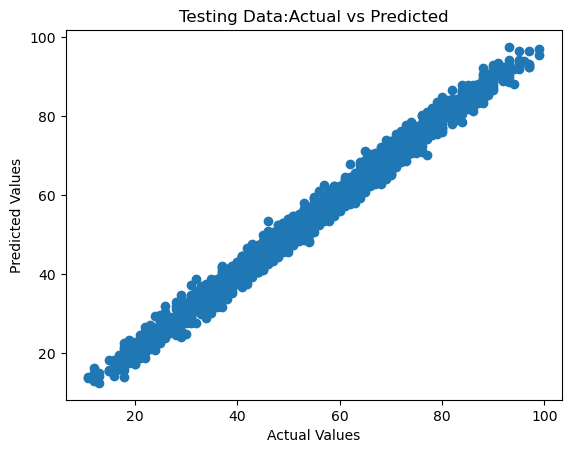

In [37]:
plt.figure()
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Testing Data:Actual vs Predicted")
plt.show()